# Weekly category planner — standalone walkthrough

Four categories, weekly data ending Sunday, 11 candidate drivers. This notebook
runs the whole pipeline in the order the tool does it:

1. configuration and ground truth
2. feature engineering
3. generating the weekly panel
4. the model
5. **feature selection, separately for every category**
6. **hyperparameter validation, separately for every category**
7. train/test split, then refit on the full history
8. driver impact — which levers matter here, and in which direction
9. forecast the selected drivers, then the two-year baseline
10. a scenario from an edited driver file

**This notebook is self-contained.** Every function it uses is defined below. It
imports nothing from the surrounding project, reads no CSV and loads no pickle —
copy the `.ipynb` anywhere with numpy, pandas, matplotlib and scipy and it runs
top to bottom.

The one architectural rule: **there is no pooled model**. Four categories, four
completely independent models. No shared coefficients, no category fixed effects,
no borrowed hyperparameters. Where you see the categories disagree below — on
which drivers matter, on how much seasonality to fit, on how long media carries
over — that disagreement is the reason.

The panel is synthetic, which means the true elasticities are known and every
estimate below can be checked rather than admired.

In [1]:
import warnings, logging
warnings.filterwarnings("ignore")

from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear

pd.set_option("display.width", 200)

# Chart styling, used throughout.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
          "#008300", "#4a3aa7", "#e34948"]
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, SURFACE = "#e1e0d9", "#fcfcfb"
POS, NEG = "#2a78d6", "#e34948"

plt.rcParams.update({
    "figure.figsize": (12, 3.6), "axes.grid": True, "grid.color": GRIDLINE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY, "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED, "font.size": 10, "figure.dpi": 110,
})
print("ready")

ready


## 1. Configuration

Everything that defines the problem: the calendar, the candidate drivers, and the
ground truth used to generate the panel.

The driver spec carries four things the pipeline reads later:

| field | what it does |
|---|---|
| `transform` | `log`, or `log1p` wherever the driver can legitimately be zero |
| `sign` | expected elasticity sign — `-1` / `+1` / `0` for no prior |
| `adstock` | eligible for media carryover (the decay is *validated*, not fixed) |
| `controllable` | can a category team actually set this number? |

`controllable` is the one that is easy to skip and turns out to matter most —
section 5.

In [2]:
# ---- calendar: weekly, week ending Sunday --------------------------------
HISTORY_START = "2022-01-02"   # a Sunday
HISTORY_END   = "2026-08-09"   # a Sunday -- 241 weeks of history
FORECAST_WEEKS = 104           # two years
TEST_WEEKS = 52                # final year held out for the train/test split
CV_FOLDS = 4                   # expanding-window folds for validation
RANDOM_SEED = 20260815

CATEGORIES = ["Ice Cream", "Ground Coffee", "Laundry Detergent", "Baby Formula"]

# ---- candidate drivers ---------------------------------------------------
DRIVERS = {
    "avg_price": dict(label="Average price ($/unit)", transform="log", sign=-1,
                      adstock=False, group="Price", controllable=True),
    "competitor_price": dict(label="Competitor avg price ($/unit)", transform="log",
                             sign=1, adstock=False, group="Price", controllable=False),
    "promo_depth": dict(label="Promo depth (avg % off)", transform="log1p", sign=1,
                        adstock=False, group="Promotion", controllable=True),
    "promo_share": dict(label="Stores on promo (% ACV)", transform="log1p", sign=1,
                        adstock=False, group="Promotion", controllable=True),
    "feature_display": dict(label="Feature + display (% ACV)", transform="log1p",
                            sign=1, adstock=False, group="Promotion", controllable=True),
    "distribution_acv": dict(label="Distribution (% ACV)", transform="log", sign=1,
                             adstock=False, group="Distribution", controllable=True),
    "tv_grps": dict(label="TV GRPs", transform="log1p", sign=1, adstock=True,
                    group="Media", controllable=True),
    "digital_spend": dict(label="Digital spend ($k)", transform="log1p", sign=1,
                          adstock=True, group="Media", controllable=True),
    "avg_temp_c": dict(label="Average temperature (C)", transform="log", sign=0,
                       adstock=False, group="External", controllable=False),
    "cpi_food": dict(label="Food CPI index", transform="log", sign=-1,
                     adstock=False, group="External", controllable=False),
    "consumer_confidence": dict(label="Consumer confidence", transform="log", sign=1,
                                adstock=False, group="External", controllable=False),
}
DRIVER_NAMES = list(DRIVERS)
ADSTOCK_DRIVERS = [n for n, s in DRIVERS.items() if s["adstock"]]

print(f"{len(CATEGORIES)} categories, {len(DRIVER_NAMES)} candidate drivers")
print("adstock-eligible:", ADSTOCK_DRIVERS)

4 categories, 11 candidate drivers
adstock-eligible: ['tv_grps', 'digital_spend']


In [3]:
# ---- ground truth used to GENERATE the panel -----------------------------
# The exact zeros are the point. Temperature does nothing to laundry detergent,
# and competitor price does nothing to baby formula -- parents do not switch
# formula on a shelf tag. Feature selection has to find those.
TRUE_ELASTICITIES = {
    "Ice Cream": {
        "avg_price": -1.90, "competitor_price": 0.55, "promo_depth": 0.45,
        "promo_share": 0.30, "feature_display": 0.35, "distribution_acv": 0.90,
        "tv_grps": 0.060, "digital_spend": 0.030, "avg_temp_c": 0.55,
        "cpi_food": -0.30, "consumer_confidence": 0.35},
    "Ground Coffee": {
        "avg_price": -2.20, "competitor_price": 0.70, "promo_depth": 0.55,
        "promo_share": 0.35, "feature_display": 0.25, "distribution_acv": 0.80,
        "tv_grps": 0.050, "digital_spend": 0.055, "avg_temp_c": 0.0,
        "cpi_food": -0.70, "consumer_confidence": 0.30},
    "Laundry Detergent": {
        "avg_price": -1.20, "competitor_price": 0.45, "promo_depth": 0.60,
        "promo_share": 0.40, "feature_display": 0.30, "distribution_acv": 1.00,
        "tv_grps": 0.030, "digital_spend": 0.020, "avg_temp_c": 0.0,
        "cpi_food": -0.50, "consumer_confidence": 0.20},
    "Baby Formula": {
        "avg_price": -0.60, "competitor_price": 0.0, "promo_depth": 0.20,
        "promo_share": 0.15, "feature_display": 0.0, "distribution_acv": 1.10,
        "tv_grps": 0.070, "digital_spend": 0.060, "avg_temp_c": 0.0,
        "cpi_food": -0.40, "consumer_confidence": 0.45},
}

# Per-category shape. `fourier_k` and `adstock_decay` are the truth the validation
# grid is trying to recover -- and they genuinely differ, which is the whole
# argument for validating each category separately.
CATEGORY_SHAPE = {
    "Ice Cream": dict(base_volume=850_000, trend=0.035, fourier_k=3,
                      # temperature already carries the summer peak as a driver,
                      # so the Fourier term only carries what is left over
                      seasonal_amp=[0.07, 0.05, 0.03], adstock_decay=0.30, peak_week=27),
    "Ground Coffee": dict(base_volume=1_250_000, trend=0.015, fourier_k=2,
                          seasonal_amp=[0.13, 0.04, 0.0], adstock_decay=0.50, peak_week=2),
    "Laundry Detergent": dict(base_volume=2_100_000, trend=-0.010, fourier_k=1,
                              seasonal_amp=[0.05, 0.0, 0.0], adstock_decay=0.70, peak_week=10),
    "Baby Formula": dict(base_volume=430_000, trend=0.025, fourier_k=1,
                         seasonal_amp=[0.03, 0.0, 0.0], adstock_decay=0.0, peak_week=1),
}

# Unobserved reality, so in-sample R^2 lands somewhere believable rather than 0.999.
LATENT_AR, LATENT_SD, NOISE_SD = 0.80, 0.030, 0.018

# ---- the validation grid: each category picks its own row ----------------
GRID = {"fourier_k": [1, 2, 3, 4],
        "adstock_decay": [0.0, 0.3, 0.5, 0.7],
        "alpha": [0.01, 0.1, 0.5, 1.0, 3.0, 10.0, 30.0]}

# Backward elimination stops once the cheapest available removal costs more than
# this fraction of CV RMSE. A driver that cheap to lose was not carrying anything.
SELECTION_TOLERANCE = 0.002

# A controllable driver whose impact clears this (% volume per 1sd) is never
# eliminated, however little it does for forecast error. Section 4b explains why.
MATERIALITY_PCT = 1.0

n_configs = len(GRID['fourier_k']) * len(GRID['adstock_decay']) * len(GRID['alpha'])
print(f"{n_configs} configurations scored per category")

112 configurations scored per category


## 2. Feature engineering

The design matrix for one category is:

```
log(driver)  for each SELECTED driver
+ linear trend (in years)
+ Fourier pairs for the yearly cycle, K of them
+ holiday-week dummies
```

No category dummies and no shared terms, because each category is fitted entirely
on its own. That is the whole architecture.

The generator and the model use these same functions, on purpose: if the two ever
disagree, the model is chasing an artefact of its own code.

In [4]:
def adstock(x, decay):
    """Carryover: a[t] = x[t] + decay * a[t-1]. Media does not spend and vanish.

    decay=0 returns the input unchanged, which is how a category says "my media has
    no carryover" without needing a separate code path.
    """
    if decay <= 0:
        return np.asarray(x, dtype=float)
    out = np.empty(len(x), dtype=float)
    carry = 0.0
    for i, v in enumerate(x):
        carry = v + decay * carry
        out[i] = carry
    return out


def apply_adstock(df, decay):
    """Apply one category's validated decay to every adstock-eligible driver.

    One decay per category rather than one per driver: with 241 weeks, fitting a
    separate carryover rate for TV and for digital is more parameters than the
    data supports.
    """
    out = df.sort_values("date").copy()
    for name in ADSTOCK_DRIVERS:
        if name in out.columns:
            out[name] = adstock(out[name].to_numpy(dtype=float), decay)
    return out


def log_driver(values, name):
    """One driver column -> its log-space feature."""
    x = np.asarray(values, dtype=float)
    if DRIVERS[name]["transform"] == "log":
        return np.log(np.clip(x, 1e-6, None))
    return np.log1p(np.clip(x, 0.0, None))


def fourier_terms(dates, k):
    """K sin/cos pairs for the yearly cycle, keyed on day-of-year.

    Day-of-year rather than week number so 53-week years do not shift the phase,
    which matters when the forecast runs two years past the history.
    """
    doy = pd.DatetimeIndex(dates).dayofyear.to_numpy(dtype=float)
    out = pd.DataFrame(index=range(len(doy)))
    for j in range(1, k + 1):
        out[f"sin{j}"] = np.sin(2 * np.pi * j * doy / 365.25)
        out[f"cos{j}"] = np.cos(2 * np.pi * j * doy / 365.25)
    return out


HOLIDAY_COLS = ["hol_yearend", "hol_thanksgiving", "hol_july4", "hol_easter"]


def holiday_flags(dates):
    """Weeks that behave differently regardless of any driver.

    Defined on ISO week number, which is what a weekly retail calendar is planned
    on. These are controls, not levers -- they never appear in a scenario.
    """
    wk = pd.DatetimeIndex(dates).isocalendar().week.to_numpy(dtype=int)
    return pd.DataFrame({
        "hol_yearend": np.isin(wk, [51, 52, 53, 1]).astype(float),
        "hol_thanksgiving": np.isin(wk, [47, 48]).astype(float),
        "hol_july4": np.isin(wk, [26, 27]).astype(float),
        "hol_easter": np.isin(wk, [13, 14, 15]).astype(float),
    }, index=range(len(wk)))


def fourier_cols(k):
    return [f"{f}{j}" for j in range(1, k + 1) for f in ("sin", "cos")]


def control_cols(k):
    """Everything that is not a driver. Controls explain WHEN volume happens;
    drivers explain WHY. Controls are never penalised and never edited."""
    return ["trend"] + fourier_cols(k) + HOLIDAY_COLS


def build_design(df, drivers, k, decay, t0):
    """The full design matrix for ONE category.

    `drivers` is that category's selected list -- a different length and a
    different membership for every category, which is the point. `t0` anchors the
    trend so history and forecast share one clock.
    """
    df = apply_adstock(df, decay).reset_index(drop=True)

    X = pd.DataFrame(index=range(len(df)))
    for name in drivers:
        X[f"l_{name}"] = log_driver(df[name].to_numpy(), name)

    X["trend"] = (pd.DatetimeIndex(df["date"]) - t0).days.to_numpy() / 365.25
    for col, vals in fourier_terms(df["date"], k).items():
        X[col] = vals.to_numpy()
    for col, vals in holiday_flags(df["date"]).items():
        X[col] = vals.to_numpy()
    return X


print("feature functions defined")

feature functions defined


## 3. Generating the weekly panel

Volume is a log-log response surface with elasticities that are known per
category. Two things are deliberately unrecoverable — a persistent AR(1) factor
and weekly noise — which is what keeps in-sample R² in a believable range.

Each category also gets its own seasonal shape and its own media carryover,
because those are the hyperparameters section 6 validates. If every category
shared them, the validation step would be theatre.

In [5]:
def weeks():
    return pd.date_range(HISTORY_START, HISTORY_END, freq="W-SUN")


def external_drivers(dates, rng):
    """Weather and macro. One real-world path, observed by all four categories.

    Shared *inputs* are not pooling: each category still fits its own response,
    and three of the four will conclude temperature does nothing.
    """
    n = len(dates)
    t = np.arange(n, dtype=float)
    doy = dates.dayofyear.to_numpy()

    # Northern-hemisphere temperature. Floored at 3C rather than zero: this is a
    # market average, and log(0.5) vs log(25) would hand ice cream a 4-unit swing
    # in log space and a frankly silly seasonal ratio.
    temp = 14.0 + 10.0 * np.sin(2 * np.pi * (doy - 105) / 365.25) + rng.normal(0, 1.2, n)

    # Food CPI: inflation running hot into 2023, then easing.
    weekly_infl = np.where(t < 78, 0.0022, np.where(t < 130, 0.0009, 0.0005))
    cpi = 100.0 * np.exp(np.cumsum(weekly_infl)) * np.exp(rng.normal(0, 0.0012, n))

    # Consumer confidence: dips with the inflation peak, recovers slowly.
    cc = 95 - 18 * np.exp(-(((t - 80) / 35.0) ** 2)) + 0.045 * t
    cc = cc * np.exp(rng.normal(0, 0.010, n))

    return pd.DataFrame({"date": dates, "avg_temp_c": np.clip(temp, 3.0, None),
                         "cpi_food": cpi, "consumer_confidence": cc})


def category_drivers(cat, dates, ext, rng):
    """The commercial levers a category team actually controls."""
    n = len(dates)
    t = np.arange(n, dtype=float)
    wk = dates.isocalendar().week.to_numpy(dtype=int)

    # Promo calendar: retail promotes into the holidays and around key seasons.
    promo_season = (0.55 * np.exp(-(((wk - 48) / 3.0) ** 2))
                    + 0.40 * np.exp(-(((wk - 26) / 4.0) ** 2))
                    + 0.25 * np.exp(-(((wk - 13) / 3.0) ** 2)))

    depth_base = {"Ice Cream": 22, "Ground Coffee": 18,
                  "Laundry Detergent": 25, "Baby Formula": 8}[cat]
    promo_depth = np.clip(depth_base * (1 + 0.5 * promo_season)
                          * np.exp(rng.normal(0, 0.16, n)), 2, 45)

    share_base = {"Ice Cream": 38, "Ground Coffee": 31,
                  "Laundry Detergent": 45, "Baby Formula": 14}[cat]
    promo_share = np.clip(share_base * (1 + 0.6 * promo_season)
                          * np.exp(rng.normal(0, 0.20, n)), 3, 85)

    feat_base = {"Ice Cream": 20, "Ground Coffee": 16,
                 "Laundry Detergent": 24, "Baby Formula": 6}[cat]
    feature_display = np.clip(feat_base * (1 + 0.7 * promo_season)
                              * np.exp(rng.normal(0, 0.28, n)), 0, 70)

    # Price: list price tracks food CPI, shelf price is net of the promo running.
    p0 = {"Ice Cream": 4.80, "Ground Coffee": 8.90,
          "Laundry Detergent": 11.50, "Baby Formula": 27.00}[cat]
    cpi_rel = ext["cpi_food"].to_numpy() / 100.0
    list_price = p0 * cpi_rel ** 0.80 * np.exp(rng.normal(0, 0.010, n))
    avg_price = list_price * (1 - (promo_share / 100.0) * (promo_depth / 100.0))

    # Competitor price: correlated with ours but with its own promo rhythm.
    competitor_price = (p0 * 0.97 * cpi_rel ** 0.78
                        * (1 - 0.6 * (promo_share / 100.0) * (promo_depth / 100.0))
                        * np.exp(rng.normal(0, 0.030, n)))

    # Distribution: a logistic build toward a category ceiling.
    d0, d1 = {"Ice Cream": (68, 87), "Ground Coffee": (74, 91),
              "Laundry Detergent": (82, 94), "Baby Formula": (61, 83)}[cat]
    dist = d0 + (d1 - d0) / (1 + np.exp(-(t - 110) / 32.0))
    dist = np.clip(dist * np.exp(rng.normal(0, 0.012, n)), 30, 98)

    # Media: flighted, with genuine dark weeks. Not a smooth spend line.
    tv_base = {"Ice Cream": 95, "Ground Coffee": 70,
               "Laundry Detergent": 55, "Baby Formula": 110}[cat]
    on_air = rng.random(n) < {"Ice Cream": 0.45, "Ground Coffee": 0.40,
                              "Laundry Detergent": 0.35, "Baby Formula": 0.55}[cat]
    tv_grps = np.where(on_air, tv_base * np.exp(rng.normal(0, 0.45, n)), 0.0)

    dig_base = {"Ice Cream": 42, "Ground Coffee": 55,
                "Laundry Detergent": 30, "Baby Formula": 75}[cat]
    digital_spend = np.clip(dig_base * (1 + 0.35 * promo_season)
                            * np.exp(rng.normal(0, 0.35, n)), 0, None)
    digital_spend[rng.random(n) < 0.05] = 0.0

    return pd.DataFrame({
        "date": dates, "category": cat, "avg_price": avg_price,
        "competitor_price": competitor_price, "promo_depth": promo_depth,
        "promo_share": promo_share, "feature_display": feature_display,
        "distribution_acv": dist, "tv_grps": tv_grps, "digital_spend": digital_spend})


def seasonal_curve(dates, shape):
    """The category's own yearly cycle, from the Fourier amplitudes in config."""
    doy = dates.dayofyear.to_numpy(dtype=float)
    peak_doy = (shape["peak_week"] - 1) * 7 + 4
    out = np.zeros(len(doy))
    for j, amp in enumerate(shape["seasonal_amp"], start=1):
        if amp:
            out += amp * np.cos(2 * np.pi * j * (doy - peak_doy) / 365.25)
    return out


def holiday_curve(dates, cat):
    """Holiday lifts that have nothing to do with any driver."""
    flags = holiday_flags(pd.Series(dates))
    lift = {
        "Ice Cream": {"hol_yearend": 0.04, "hol_thanksgiving": 0.05,
                      "hol_july4": 0.14, "hol_easter": 0.03},
        "Ground Coffee": {"hol_yearend": 0.10, "hol_thanksgiving": 0.09,
                          "hol_july4": -0.03, "hol_easter": 0.02},
        "Laundry Detergent": {"hol_yearend": -0.05, "hol_thanksgiving": 0.03,
                              "hol_july4": -0.02, "hol_easter": 0.02},
        "Baby Formula": {"hol_yearend": 0.02, "hol_thanksgiving": 0.01,
                         "hol_july4": 0.0, "hol_easter": 0.0},
    }[cat]
    return sum(lift[c] * flags[c].to_numpy() for c in flags.columns)


def generate_panel():
    rng = np.random.default_rng(RANDOM_SEED)
    dates = weeks()
    ext = external_drivers(dates, rng)

    frames = []
    for cat in CATEGORIES:
        shape, betas = CATEGORY_SHAPE[cat], TRUE_ELASTICITIES[cat]
        n = len(dates)

        df = category_drivers(cat, dates, ext, rng).merge(ext, on="date")
        # Apply this category's carryover before reading the elasticities off,
        # exactly as the model will when it fits.
        adstocked = apply_adstock(df, shape["adstock_decay"])

        contrib = np.zeros(n)
        for name in DRIVER_NAMES:
            if not betas[name]:
                continue                     # a true zero: this driver does nothing here
            lx = log_driver(adstocked[name].to_numpy(), name)
            contrib += betas[name] * (lx - lx.mean())

        latent = np.zeros(n)
        for i in range(1, n):
            latent[i] = LATENT_AR * latent[i - 1] + rng.normal(0, LATENT_SD)

        log_v = (np.log(shape["base_volume"])
                 + shape["trend"] * np.arange(n) / 52.0
                 + seasonal_curve(dates, shape)
                 + holiday_curve(dates, cat)
                 + contrib + latent + rng.normal(0, NOISE_SD, n))
        df["volume"] = np.round(np.exp(log_v))
        frames.append(df)

    panel = pd.concat(frames, ignore_index=True)
    cols = ["date", "category", "volume"] + DRIVER_NAMES
    return panel[cols].sort_values(["category", "date"]).reset_index(drop=True)


def true_elasticity_table():
    return pd.DataFrame(TRUE_ELASTICITIES).T.loc[CATEGORIES, DRIVER_NAMES]


panel = generate_panel()
t0 = pd.Timestamp(HISTORY_START)
print(f"{len(panel)} rows | {panel['date'].nunique()} weeks | "
      f"{panel['date'].min().date()} -> {panel['date'].max().date()}")
print("Every date is a Sunday:", set(panel["date"].dt.day_name()))
panel.head()

964 rows | 241 weeks | 2022-01-02 -> 2026-08-09
Every date is a Sunday: {'Sunday'}


,date,category,volume,avg_price,competitor_price,promo_depth,promo_share,feature_display,distribution_acv,tv_grps,digital_spend,avg_temp_c,cpi_food,consumer_confidence
0,2022-01-02,Baby Formula,514956.0,27.375777,25.859245,9.142307,11.794427,7.884883,61.621116,160.486112,97.815394,4.503747,100.241304,93.867892
1,2022-01-09,Baby Formula,516819.0,26.777150,26.209876,6.494555,10.897387,5.275245,61.204145,125.607564,158.691555,4.688961,100.413844,93.329409
2,2022-01-16,Baby Formula,389027.0,26.780654,26.991080,8.559843,14.988283,5.191469,59.718411,0.000000,95.174225,4.091193,100.686569,93.994003
3,2022-01-23,Baby Formula,397825.0,26.245947,25.458592,9.835754,15.795598,9.063909,61.614537,0.000000,105.576185,3.908166,100.969926,94.439860
4,2022-01-30,Baby Formula,350386.0,27.391034,26.913799,7.645557,9.461811,2.562340,61.819143,0.000000,103.047307,4.192287,101.189728,94.612270


### The data

Four categories that behave nothing like each other. Ice cream triples between
winter and summer; laundry detergent is flat all year. That difference is not a
nuisance to be absorbed by a fixed effect — it is the reason each category needs
its own model.

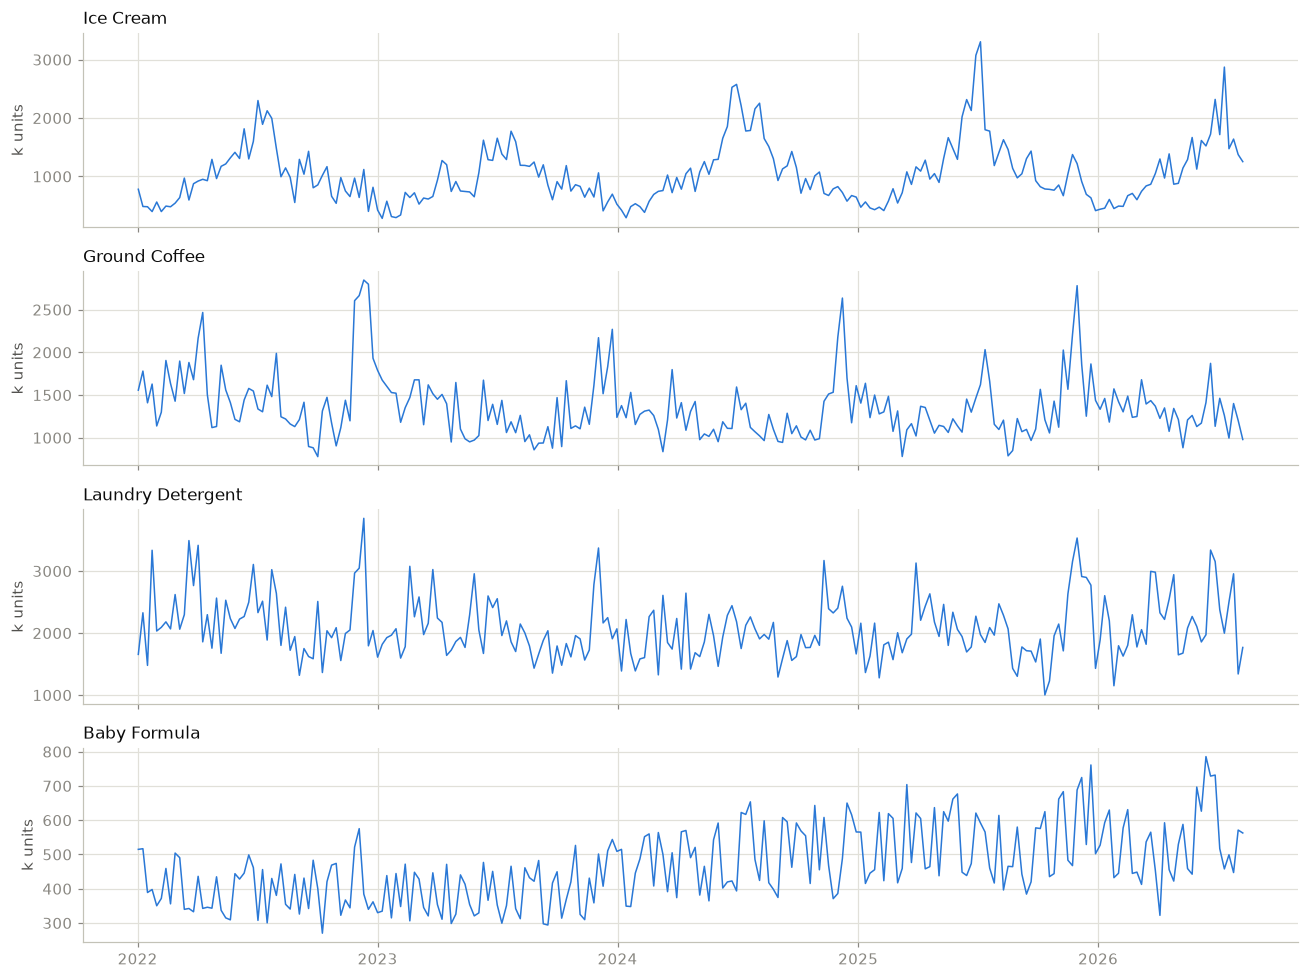

Summer / winter volume ratio:
category
Baby Formula         0.99
Ground Coffee        0.80
Ice Cream            2.97
Laundry Detergent    1.02


In [6]:
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, cat in zip(axes, CATEGORIES):
    s = panel[panel.category == cat]
    ax.plot(s["date"], s["volume"] / 1e3, color=SERIES[0], lw=1)
    ax.set_title(cat, loc="left", fontsize=11, color=INK_PRIMARY)
    ax.set_ylabel("k units")
plt.tight_layout(); plt.show()

summer = panel[panel.date.dt.month.isin([6, 7, 8])].groupby("category")["volume"].mean()
winter = panel[panel.date.dt.month.isin([12, 1, 2])].groupby("category")["volume"].mean()
print("Summer / winter volume ratio:")
print((summer / winter).round(2).to_string())

In [7]:
truth = true_elasticity_table()
print("True elasticities (0 = this driver genuinely does nothing in this category):")
truth

True elasticities (0 = this driver genuinely does nothing in this category):


,avg_price,competitor_price,promo_depth,promo_share,feature_display,distribution_acv,tv_grps,digital_spend,avg_temp_c,cpi_food,consumer_confidence
Ice Cream,-1.9,0.55,0.45,0.30,0.35,0.9,0.06,0.030,0.55,-0.3,0.35
Ground Coffee,-2.2,0.70,0.55,0.35,0.25,0.8,0.05,0.055,0.00,-0.7,0.30
Laundry Detergent,-1.2,0.45,0.60,0.40,0.30,1.0,0.03,0.020,0.00,-0.5,0.20
Baby Formula,-0.6,0.00,0.20,0.15,0.00,1.1,0.07,0.060,0.00,-0.4,0.45


## 4. The model

One model per category, a log-log ridge:

```
log(volume) = intercept
            + SUM_d  beta_d * log(driver_d)      <- the elasticities
            + trend + yearly seasonality + holiday weeks
```

`beta_d` reads directly as an elasticity: the % change in volume for a 1% change
in that driver. Ridge rather than plain least squares because price, promo depth
and promo share move together in real retail data, and shrinkage is the point.

Three deliberate choices:

- **Only driver coefficients are penalised.** Trend, seasonality and holidays are
  controls; shrinking them would distort the calendar to buy a smaller elasticity,
  which is backwards.
- **Coefficients carry sign constraints.** A planner shown "raise price to sell
  more" stops trusting the tool, and price is entangled enough with promotion that
  an unconstrained fit occasionally produces exactly that.
- **Validation is per category** on expanding-window folds. Random k-fold would let
  the model train on next winter to predict last winter, which for a forecasting
  tool is cheating with extra steps.

In [8]:
def fit_ridge(X, y, alpha, penalise, lo, hi):
    """Sign-constrained ridge, solved as a bounded least-squares problem.

    The ridge penalty is applied by stacking sqrt(alpha)*I under the design and
    zeros under the response -- the standard Tikhonov trick -- which turns "ridge
    with bounds" into an ordinary bounded least-squares call. Both sides are
    centred first so the intercept is fitted but never penalised or constrained.

    `penalise` is a 0/1 weight per column: 1 for drivers, 0 for controls.
    """
    x_mean, y_mean = X.mean(axis=0), y.mean()
    Xc, yc = X - x_mean, y - y_mean

    A = np.vstack([Xc, np.sqrt(alpha) * np.diag(penalise)])
    b = np.concatenate([yc, np.zeros(X.shape[1])])
    res = lsq_linear(A, b, bounds=(lo, hi), method="bvls", max_iter=500)

    coef = res.x
    return coef, float(y_mean - x_mean @ coef)


def coef_bounds(cols):
    """Sign constraints per design column. Controls free; drivers follow config."""
    lo, hi = [], []
    for c in cols:
        sign = DRIVERS[c[2:]]["sign"] if c.startswith("l_") else 0
        lo.append(-np.inf if sign <= 0 else 0.0)
        hi.append(np.inf if sign >= 0 else 0.0)
    return np.array(lo), np.array(hi)


def penalty_weights(cols):
    """Shrink elasticities, never the calendar."""
    return np.array([1.0 if c.startswith("l_") else 0.0 for c in cols])


def scale_cols(X):
    """Standardise so one alpha means the same thing to every driver."""
    sd = X.std(axis=0, ddof=0)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return X / sd, sd


def fit_design(X, y, alpha):
    """Fit on a built design; returns raw (unscaled) coefficients and intercept."""
    cols = list(X.columns)
    Xs, sd = scale_cols(X.to_numpy(dtype=float))
    lo, hi = coef_bounds(cols)
    coef_s, intercept = fit_ridge(Xs, y, alpha, penalty_weights(cols), lo, hi)
    return pd.Series(coef_s / sd, index=cols), intercept   # unscale -> elasticities


def time_folds(n, n_folds=CV_FOLDS):
    """Expanding-window folds: always train on the past, test on the future."""
    edges = np.linspace(n // 2, n, n_folds + 1).astype(int)
    for i in range(n_folds):
        train = np.arange(0, edges[i])
        test = np.arange(edges[i], edges[i + 1])
        if len(train) and len(test):
            yield train, test


def cv_rmse(df, drivers, k, decay, alpha, t0):
    """Mean out-of-fold RMSE in log space, for one category and one config.

    The design is built once over the whole history then sliced. Rebuilding it per
    fold would restart the media adstock at each boundary and understate carryover.
    """
    X = build_design(df, drivers, k, decay, t0)
    y = np.log(df["volume"].to_numpy(dtype=float))

    errs = []
    for tr, te in time_folds(len(df)):
        coef, intercept = fit_design(X.iloc[tr], y[tr], alpha)
        pred = X.iloc[te].to_numpy() @ coef.to_numpy() + intercept
        errs.append(np.sqrt(np.mean((y[te] - pred) ** 2)))
    return float(np.mean(errs))


def choose_config(df, drivers, t0, grid=None):
    """Search the grid for this category's best (fourier_k, adstock_decay, alpha).

    Returns the winner and the full scored grid, so the choice can be inspected
    rather than taken on trust.
    """
    grid = grid or GRID
    rows = []
    for k in grid["fourier_k"]:
        for decay in grid["adstock_decay"]:
            for alpha in grid["alpha"]:
                rows.append({"fourier_k": k, "adstock_decay": decay, "alpha": alpha,
                             "cv_rmse": cv_rmse(df, drivers, k, decay, alpha, t0)})
    table = pd.DataFrame(rows).sort_values("cv_rmse").reset_index(drop=True)
    best = table.iloc[0]
    return ({"fourier_k": int(best["fourier_k"]),
             "adstock_decay": float(best["adstock_decay"]),
             "alpha": float(best["alpha"])}, table)


def best_alpha(df, drivers, k, decay, t0, alphas=None):
    """Tune only the ridge strength, holding shape fixed. Used during selection."""
    alphas = alphas or GRID["alpha"]
    rmse, a = min((cv_rmse(df, drivers, k, decay, a, t0), a) for a in alphas)
    return a, rmse


print("model functions defined")

model functions defined


In [9]:
@dataclass
class CategoryModel:
    """One category's model. It knows nothing about any other category."""
    category: str
    drivers: list
    fourier_k: int
    adstock_decay: float
    alpha: float
    coef: pd.Series
    intercept: float
    t0: pd.Timestamp
    log_sd: pd.Series          # historic sd of each log driver: the impact scale
    metrics: dict = field(default_factory=dict)
    selection: dict = field(default_factory=dict)

    @property
    def elasticities(self):
        return pd.Series({d: float(self.coef[f"l_{d}"]) for d in self.drivers})

    def design(self, df):
        return build_design(df, self.drivers, self.fourier_k, self.adstock_decay, self.t0)

    def predict(self, df):
        X = self.design(df)
        return np.exp(X[self.coef.index].to_numpy() @ self.coef.to_numpy() + self.intercept)

    def impacts(self):
        """How much each driver moves this category's volume, and which direction.

        `impact_pct` is the signed % volume change from a one-standard-deviation
        move, using that driver's own historic variation. It answers "how much does
        this lever actually matter here", which elasticity alone does not: a big
        elasticity on a driver that never moves is not a lever.
        """
        rows = []
        for d in self.drivers:
            e, sd = float(self.elasticities[d]), float(self.log_sd[d])
            rows.append({"driver": d, "label": DRIVERS[d]["label"],
                         "group": DRIVERS[d]["group"], "elasticity": e, "log_sd": sd,
                         "impact_pct": 100.0 * (np.exp(e * sd) - 1),
                         "direction": "increases volume" if e > 0 else "decreases volume"})
        out = pd.DataFrame(rows)
        out["abs_impact"] = out["impact_pct"].abs()
        return (out.sort_values("abs_impact", ascending=False)
                   .drop(columns="abs_impact").reset_index(drop=True))


def fit_category(df, category, drivers, config, t0):
    """Fit one category on the rows given. `df` must be that category only."""
    df = df.sort_values("date").reset_index(drop=True)
    k, decay, alpha = config["fourier_k"], config["adstock_decay"], config["alpha"]

    X = build_design(df, drivers, k, decay, t0)
    y = np.log(df["volume"].to_numpy(dtype=float))
    coef, intercept = fit_design(X, y, alpha)

    return CategoryModel(
        category=category, drivers=list(drivers), fourier_k=k, adstock_decay=decay,
        alpha=alpha, coef=coef, intercept=intercept, t0=t0,
        log_sd=pd.Series({d: float(X[f"l_{d}"].std(ddof=1)) for d in drivers}))


def score(model, df):
    """Accuracy of a fitted model on any slice of that category's data."""
    actual = df["volume"].to_numpy(dtype=float)
    pred = model.predict(df)
    resid_log = np.log(actual) - np.log(pred)
    ss_res = float(np.sum(resid_log ** 2))
    ss_tot = float(np.sum((np.log(actual) - np.log(actual).mean()) ** 2))
    return {"n_weeks": int(len(df)),
            "mape": float(np.mean(np.abs(pred / actual - 1)) * 100),
            "wape": float(np.sum(np.abs(pred - actual)) / np.sum(actual) * 100),
            "r2_log": float(1 - ss_res / ss_tot) if ss_tot else float("nan"),
            "bias_pct": float((pred.sum() / actual.sum() - 1) * 100)}


print("CategoryModel defined")

CategoryModel defined


## 5. Feature selection, per category

Backward elimination scored on **expanding-window cross-validation**. Start with
all 11 drivers. Repeatedly ask "what happens to out-of-fold error if I drop this
one?", and drop the cheapest — while it stays cheap.

In-sample fit could not do this job: adding a driver can only ever improve it, so
in-sample selection keeps everything and answers nothing.

Two guards stop pure error-chasing from building the wrong tool.

**The sign prior.** A driver whose *unconstrained* elasticity contradicts its
business prior is removed before the search starts. Fitted unconstrained on
purpose — the disagreement is the signal, and a constrained fit would silently pin
the coefficient at zero and let the driver look fine.

**Lever protection.** The first version of this pipeline selected purely on CV
error, and it dropped `avg_price` from Laundry Detergent while keeping
`competitor_price`. That is not a bug in the search: our price and the
competitor's price move together — both track food CPI, both respond to the same
promo calendar — so out-of-fold error genuinely cannot separate them, and swapping
one for the other costs nothing measurable. As a *forecast*, fine. As a *planning
tool*, useless: it deletes the one number the category team actually sets and
replaces it with a number they can only watch.

So a `controllable` driver is protected from elimination when its estimated impact
clears `MATERIALITY_PCT`. The threshold is what keeps this from becoming blanket
protection — a controllable driver the model finds genuinely inert is still
dropped, which is exactly what happens to feature+display in baby formula, whose
true elasticity is zero.

In [10]:
def sign_check(df, drivers, k, decay, t0):
    """Drivers whose UNCONSTRAINED elasticity contradicts the business prior."""
    X = build_design(df, drivers, k, decay, t0)
    y = np.log(df["volume"].to_numpy(dtype=float))

    cols = list(X.columns)
    Xs, sd = scale_cols(X.to_numpy(dtype=float))
    free_lo, free_hi = np.full(len(cols), -np.inf), np.full(len(cols), np.inf)
    coef_s, _ = fit_ridge(Xs, y, 1.0, penalty_weights(cols), free_lo, free_hi)
    coef = pd.Series(coef_s / sd, index=cols)

    bad = []
    for d in drivers:
        prior, e = DRIVERS[d]["sign"], float(coef[f"l_{d}"])
        if prior != 0 and np.sign(e) == -prior and abs(e) > 0.01:
            bad.append(d)
    return bad


def protected_drivers(df, kept, k, decay, alpha, t0):
    """Controllable levers the model finds material. Never eliminated."""
    m = fit_category(df, "tmp", kept,
                     {"fourier_k": k, "adstock_decay": decay, "alpha": alpha}, t0)
    impacts = m.impacts().set_index("driver")["impact_pct"].abs()
    return [d for d in kept
            if DRIVERS[d]["controllable"] and impacts.get(d, 0.0) >= MATERIALITY_PCT]


def backward_eliminate(df, drivers, k, decay, t0,
                       tolerance=SELECTION_TOLERANCE, verbose=False):
    """Drop drivers while out-of-fold error does not meaningfully worsen.

    `tolerance` is a fraction of the current CV RMSE. Every driver kept is one more
    series someone has to forecast, maintain and explain.
    """
    kept = list(drivers)
    alpha, rmse = best_alpha(df, kept, k, decay, t0)
    log = [{"step": 0, "removed": None, "n_drivers": len(kept),
            "cv_rmse": rmse, "alpha": alpha}]

    step = 0
    while len(kept) > 1:
        protected = protected_drivers(df, kept, k, decay, alpha, t0)
        removable = [d for d in kept if d not in protected]
        if not removable:
            break

        candidates = []
        for d in removable:
            a, r = best_alpha(df, [x for x in kept if x != d], k, decay, t0)
            candidates.append((r, d, a))
        candidates.sort()
        best_rmse, drop, best_a = candidates[0]

        if best_rmse > rmse * (1 + tolerance):
            break                                  # everything left is earning its place

        step += 1
        kept = [x for x in kept if x != drop]
        rmse, alpha = best_rmse, best_a
        log.append({"step": step, "removed": drop, "n_drivers": len(kept),
                    "cv_rmse": rmse, "alpha": alpha})
        if verbose:
            print(f"      drop {drop:<22} -> {len(kept):2d} drivers, cv_rmse {rmse:.5f}")

    return kept, pd.DataFrame(log)


def select_for_category(df, category, t0, verbose=True):
    """The full routine for one category. `df` is that category's TRAIN rows.

    Order matters. Shape is settled first with every driver present, so the search
    is not comparing driver sets across different seasonal models. Then drivers are
    eliminated. Then shape is re-validated on the survivors, because the right
    number of harmonics can change once drivers carrying part of the seasonality
    are gone.
    """
    candidates = list(DRIVER_NAMES)
    if verbose:
        print(f"    [1/4] tuning shape with all {len(candidates)} drivers ...")
    shape, _ = choose_config(df, candidates, t0)

    if verbose:
        print(f"          k={shape['fourier_k']}, decay={shape['adstock_decay']}, "
              f"alpha={shape['alpha']}")
        print("    [2/4] checking elasticity signs against the business prior ...")
    wrong_sign = sign_check(df, candidates, shape["fourier_k"], shape["adstock_decay"], t0)
    survivors = [d for d in candidates if d not in wrong_sign]
    if verbose:
        print(f"          dropped for wrong sign: {', '.join(wrong_sign) or 'none'}")
        print("    [3/4] backward elimination on out-of-fold error ...")

    kept, log = backward_eliminate(df, survivors, shape["fourier_k"],
                                   shape["adstock_decay"], t0, verbose=verbose)

    if verbose:
        print(f"    [4/4] re-tuning shape on the {len(kept)} selected drivers ...")
    final, grid = choose_config(df, kept, t0)
    if verbose:
        print(f"          k={final['fourier_k']}, decay={final['adstock_decay']}, "
              f"alpha={final['alpha']}")

    return {"category": category, "selected": kept,
            "dropped": [d for d in candidates if d not in kept],
            "dropped_wrong_sign": wrong_sign, "config": final,
            "config_with_all_drivers": shape, "elimination_log": log, "grid": grid}


print("selection functions defined")

selection functions defined


Run it for one category. Selection uses the **training rows only** — selecting on
all 241 weeks and then reporting accuracy on the last 52 would leak the test set
into the feature list.

In [11]:
cat = "Ground Coffee"
df = panel[panel.category == cat].sort_values("date").reset_index(drop=True)
cut = df.date.max() - pd.Timedelta(weeks=TEST_WEEKS)
train, test = df[df.date <= cut], df[df.date > cut]
print(f"{cat}: train {len(train)} weeks, test {len(test)} weeks\n")

result = select_for_category(train, cat, t0)
print(f"\nKept    ({len(result['selected'])}): {', '.join(result['selected'])}")
print(f"Dropped ({len(result['dropped'])}): {', '.join(result['dropped']) or 'none'}")

Ground Coffee: train 189 weeks, test 52 weeks

    [1/4] tuning shape with all 11 drivers ...


          k=3, decay=0.5, alpha=3.0
    [2/4] checking elasticity signs against the business prior ...
          dropped for wrong sign: none
    [3/4] backward elimination on out-of-fold error ...
      drop cpi_food               -> 10 drivers, cv_rmse 0.06255


      drop avg_temp_c             ->  9 drivers, cv_rmse 0.06218
    [4/4] re-tuning shape on the 9 selected drivers ...


          k=3, decay=0.5, alpha=0.5

Kept    (9): avg_price, competitor_price, promo_depth, promo_share, feature_display, distribution_acv, tv_grps, digital_spend, consumer_confidence
Dropped (2): avg_temp_c, cpi_food


In [12]:
print("Backward elimination trace -- each row drops the driver that costs least:")
result["elimination_log"]

Backward elimination trace -- each row drops the driver that costs least:


,step,removed,n_drivers,cv_rmse,alpha
0,0,NaN,11,0.063498,3.0
1,1,cpi_food,10,0.062546,1.0
2,2,avg_temp_c,9,0.062185,0.5


### Lever protection, demonstrated

Same category, same data, selection run both ways.

In [13]:
ld_train = panel[panel.category == "Laundry Detergent"].sort_values("date")
ld_train = ld_train[ld_train.date <= ld_train.date.max() - pd.Timedelta(weeks=TEST_WEEKS)]
shape, _ = choose_config(ld_train, list(DRIVER_NAMES), t0)

saved = MATERIALITY_PCT
MATERIALITY_PCT = 1e9          # nothing is protected
unprotected, _ = backward_eliminate(ld_train, list(DRIVER_NAMES),
                                    shape["fourier_k"], shape["adstock_decay"], t0)
MATERIALITY_PCT = saved
protected, _ = backward_eliminate(ld_train, list(DRIVER_NAMES),
                                  shape["fourier_k"], shape["adstock_decay"], t0)

print("Laundry Detergent, selection WITHOUT lever protection:")
print("  ", ", ".join(unprotected))
print("   avg_price kept?", "avg_price" in unprotected)
print("\nLaundry Detergent, selection WITH lever protection:")
print("  ", ", ".join(protected))
print("   avg_price kept?", "avg_price" in protected)

Laundry Detergent, selection WITHOUT lever protection:
   competitor_price, promo_depth, promo_share, feature_display, distribution_acv, tv_grps, cpi_food
   avg_price kept? False

Laundry Detergent, selection WITH lever protection:
   avg_price, competitor_price, promo_depth, promo_share, feature_display, distribution_acv, tv_grps, cpi_food
   avg_price kept? True


## 6. Hyperparameter validation, per category

Three things are tuned, and all three genuinely differ between categories:

| | what it controls |
|---|---|
| `fourier_k` | how many harmonics the yearly seasonality gets |
| `adstock_decay` | how long media carries over |
| `alpha` | ridge strength on the elasticities |

Every combination is scored on the same expanding-window folds. Ice cream needs a
richer seasonal shape than baby formula; laundry's media carries over for weeks
while baby formula's does not carry at all. One global config would be wrong for
at least three of the four.

In [14]:
print(f"{cat}: top 8 of {len(result['grid'])} configurations")
result["grid"].head(8)

Ground Coffee: top 8 of 112 configurations


,fourier_k,adstock_decay,alpha,cv_rmse
0,3,0.5,0.50,0.062185
1,3,0.5,1.00,0.062239
2,3,0.5,0.10,0.062319
3,3,0.5,0.01,0.062382
4,3,0.5,3.00,0.063369
5,4,0.5,1.00,0.063938
6,4,0.5,0.50,0.064132
7,4,0.5,0.10,0.064617


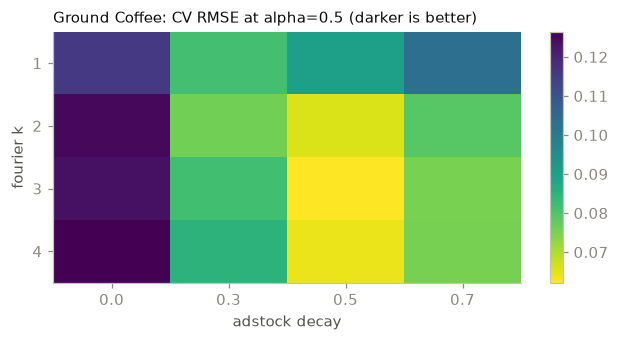

In [15]:
g = result["grid"]
ba = g.iloc[0]["alpha"]
sub = g[g.alpha == ba].pivot(index="fourier_k", columns="adstock_decay", values="cv_rmse")

fig, ax = plt.subplots(figsize=(6, 3.2))
im = ax.imshow(sub.values, cmap="viridis_r", aspect="auto")
ax.set_xticks(range(len(sub.columns)), sub.columns)
ax.set_yticks(range(len(sub.index)), sub.index)
ax.set_xlabel("adstock decay"); ax.set_ylabel("fourier k")
ax.set_title(f"{cat}: CV RMSE at alpha={ba} (darker is better)", loc="left", fontsize=10)
ax.grid(False); plt.colorbar(im); plt.tight_layout(); plt.show()

## 7. Train / test, then refit on everything

The test score comes from a model that saw neither the test weeks nor — crucially
— let them influence which features exist.

The model that actually ships is refitted on the full history with the same
recipe. Holding out the most recent year forever, just to preserve a number
already recorded, would throw away the most relevant data in the panel.

Trained on the first 189 weeks only:
  train: {'n_weeks': 189, 'mape': 3.077, 'wape': 3.122, 'r2_log': 0.976, 'bias_pct': -0.114}
  test : {'n_weeks': 52, 'mape': 7.018, 'wape': 7.211, 'r2_log': 0.849, 'bias_pct': -6.956}

Refitted on all 241 weeks -- this is the model that ships.


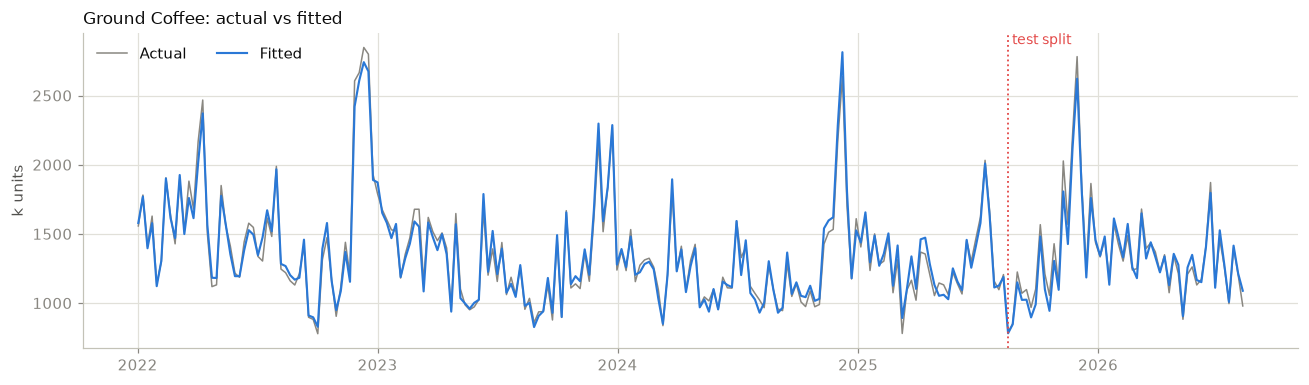

In [16]:
train_model = fit_category(train, cat, result["selected"], result["config"], t0)
print("Trained on the first", len(train), "weeks only:")
print("  train:", {k: round(v, 3) for k, v in score(train_model, train).items()})
print("  test :", {k: round(v, 3) for k, v in score(train_model, test).items()})

final = fit_category(df, cat, result["selected"], result["config"], t0)
print("\nRefitted on all", len(df), "weeks -- this is the model that ships.")

fig, ax = plt.subplots()
ax.plot(df["date"], df["volume"] / 1e3, color=INK_MUTED, lw=1, label="Actual")
ax.plot(df["date"], final.predict(df) / 1e3, color=SERIES[0], lw=1.4, label="Fitted")
ax.axvline(test["date"].min(), color=NEG, ls=":", lw=1.2)
ax.text(test["date"].min(), ax.get_ylim()[1], " test split", va="top",
        fontsize=9, color=NEG)
ax.set_ylabel("k units"); ax.legend(frameon=False, ncol=2)
ax.set_title(f"{cat}: actual vs fitted", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

Now every category, end to end.

In [17]:
models, rows = {}, []
for c in CATEGORIES:
    d = panel[panel.category == c].sort_values("date").reset_index(drop=True)
    cutc = d.date.max() - pd.Timedelta(weeks=TEST_WEEKS)
    tr, te = d[d.date <= cutc], d[d.date > cutc]

    r = select_for_category(tr, c, t0, verbose=False)
    tm = fit_category(tr, c, r["selected"], r["config"], t0)   # honest test score
    fm = fit_category(d, c, r["selected"], r["config"], t0)    # the model that ships
    fm.metrics = {"train": score(tm, tr), "test": score(tm, te)}
    fm.selection = r
    models[c] = fm

    rows.append({"category": c, "drivers": len(r["selected"]), **r["config"],
                 "train MAPE %": fm.metrics["train"]["mape"],
                 "test MAPE %": fm.metrics["test"]["mape"],
                 "test R2 log": fm.metrics["test"]["r2_log"],
                 "test bias %": fm.metrics["test"]["bias_pct"]})

pd.DataFrame(rows).set_index("category").round(3)

,drivers,fourier_k,adstock_decay,alpha,train MAPE %,test MAPE %,test R2 log,test bias %
category,,,,,,,,
Ice Cream,10,3,0.5,0.01,3.116,7.885,0.937,-8.342
Ground Coffee,9,3,0.5,0.50,3.077,7.018,0.849,-6.956
Laundry Detergent,8,1,0.7,3.00,3.697,3.820,0.969,-1.026
Baby Formula,8,1,0.0,0.01,3.468,4.640,0.915,3.398


Read the `fourier_k` and `adstock_decay` columns against the truth in
`CATEGORY_SHAPE`. The categories were generated with different seasonal shapes and
different media carryover, and validating each one separately recovers that. A
single shared config could not have.

In [18]:
print("Validated config vs the truth used to generate the data:\n")
cmp = pd.DataFrame({
    c: {"fourier_k (true)": CATEGORY_SHAPE[c]["fourier_k"],
        "fourier_k (found)": models[c].fourier_k,
        "adstock (true)": CATEGORY_SHAPE[c]["adstock_decay"],
        "adstock (found)": models[c].adstock_decay}
    for c in CATEGORIES}).T
print(cmp.to_string())

print("\n\nSelected drivers, per category:\n")
for c, m in models.items():
    dropped = [d for d in DRIVER_NAMES if d not in m.drivers]
    print(f"{c}\n   kept    ({len(m.drivers)}): {', '.join(m.drivers)}")
    print(f"   dropped ({len(dropped)}): {', '.join(dropped) or 'none'}\n")

print("Did selection find the true zeros?")
for c, m in models.items():
    zeros = [d for d in DRIVER_NAMES if truth.loc[c, d] == 0]
    found = [d for d in zeros if d not in m.drivers]
    kept_real = [d for d in DRIVER_NAMES if truth.loc[c, d] != 0 and d in m.drivers]
    print(f"  {c:<20} true zeros dropped {len(found)}/{len(zeros)}   "
          f"real drivers kept {len(kept_real)}/{int((truth.loc[c] != 0).sum())}")

Validated config vs the truth used to generate the data:

                   fourier_k (true)  fourier_k (found)  adstock (true)  adstock (found)
Ice Cream                       3.0                3.0             0.3              0.5
Ground Coffee                   2.0                3.0             0.5              0.5
Laundry Detergent               1.0                1.0             0.7              0.7
Baby Formula                    1.0                1.0             0.0              0.0


Selected drivers, per category:

Ice Cream
   kept    (10): avg_price, competitor_price, promo_depth, promo_share, feature_display, distribution_acv, tv_grps, digital_spend, avg_temp_c, consumer_confidence
   dropped (1): cpi_food

Ground Coffee
   kept    (9): avg_price, competitor_price, promo_depth, promo_share, feature_display, distribution_acv, tv_grps, digital_spend, consumer_confidence
   dropped (2): avg_temp_c, cpi_food

Laundry Detergent
   kept    (8): avg_price, competitor_price, pro

## 8. Driver impact — which levers matter, and which way

Two numbers, and the difference between them matters:

- **elasticity** — % change in volume for a 1% change in the driver.
- **impact** — % change in volume for a *one-standard-deviation* move, using that
  category's own history.

Elasticity alone overstates a driver that never moves. A −2.2 price elasticity on
a price that varies by 3% is a smaller lever than a +0.06 media elasticity on a
budget that swings by half. Impact is the one to plan against; elasticity is the
one to sanity-check against the truth.

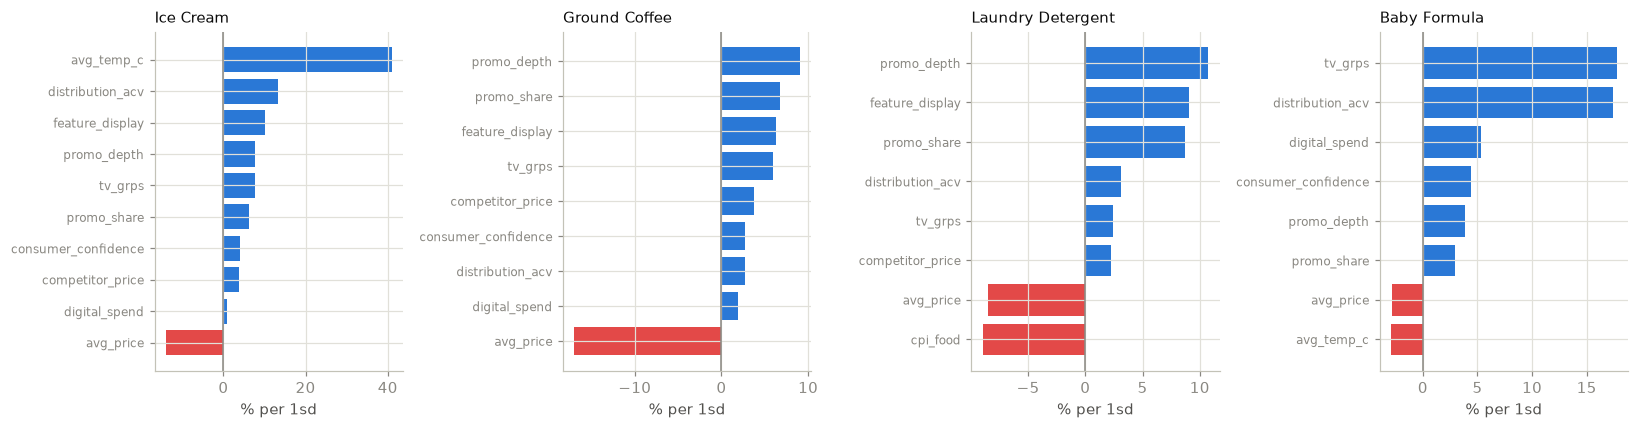

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (c, m) in zip(axes, models.items()):
    imp = m.impacts().sort_values("impact_pct")
    ax.barh(range(len(imp)), imp["impact_pct"],
            color=[POS if v > 0 else NEG for v in imp["impact_pct"]])
    ax.set_yticks(range(len(imp)), imp["driver"], fontsize=8)
    ax.axvline(0, color=INK_MUTED, lw=1)
    ax.set_title(c, loc="left", fontsize=10)
    ax.set_xlabel("% per 1sd")
plt.tight_layout(); plt.show()

In [20]:
print(f"{cat} -- impact table, sorted by how much the lever actually matters:")
models[cat].impacts().round(3)

Ground Coffee -- impact table, sorted by how much the lever actually matters:


,driver,label,group,elasticity,log_sd,impact_pct,direction
0,avg_price,Average price ($/unit),Price,-2.853,0.065,-16.971,decreases volume
1,promo_depth,Promo depth (avg % off),Promotion,0.518,0.167,9.058,increases volume
2,promo_share,Stores on promo (% ACV),Promotion,0.323,0.204,6.805,increases volume
3,feature_display,Feature + display (% ACV),Promotion,0.222,0.274,6.290,increases volume
4,tv_grps,TV GRPs,Media,0.043,1.339,5.916,increases volume
5,competitor_price,Competitor avg price ($/unit),Price,0.551,0.066,3.725,increases volume
6,consumer_confidence,Consumer confidence,External,0.306,0.086,2.678,increases volume
7,distribution_acv,Distribution (% ACV),Distribution,0.359,0.073,2.659,increases volume
8,digital_spend,Digital spend ($k),Media,0.077,0.244,1.902,increases volume


In [21]:
est = pd.DataFrame({c: {d: float(models[c].elasticities.get(d, 0.0))
                        for d in DRIVER_NAMES} for c in CATEGORIES}).T
err = (est - truth).abs()
print("Estimated elasticity (dropped drivers show as 0):")
print(est.round(3).to_string())
print("\nMean absolute error vs the truth, per category:")
print(err.mean(axis=1).round(4).to_string())

Estimated elasticity (dropped drivers show as 0):
                   avg_price  competitor_price  promo_depth  promo_share  feature_display  distribution_acv  tv_grps  digital_spend  avg_temp_c  cpi_food  consumer_confidence
Ice Cream             -2.094             0.516        0.423        0.274            0.364             1.443    0.083          0.033       0.540     0.000                0.463
Ground Coffee         -2.853             0.551        0.518        0.323            0.222             0.359    0.043          0.077       0.000     0.000                0.306
Laundry Detergent     -1.161             0.327        0.612        0.373            0.297             0.632    0.024          0.000       0.000    -1.228                0.000
Baby Formula          -0.453             0.000        0.232        0.147            0.000             1.493    0.070          0.060      -0.046     0.000                0.499

Mean absolute error vs the truth, per category:
Ice Cream            0.117

## 9. Forecast the selected drivers, then the baseline

Each `(category, driver)` pair is forecast on its own — the same driver can look
completely different for two categories, and nothing forces them to agree.

Only **selected** drivers are forecast. That is most of the practical payoff of
doing selection first: the forecasting work, and the maintenance of those
forecasts, scales with the drivers you actually use rather than with everything
you happen to collect.

Prophet is used if it is installed, with a transparent trend + week-of-year
fallback otherwise. Forecasts are held inside a plausible envelope around observed
history, because two years is a long extrapolation for a weekly series and a mild
trend can otherwise drift somewhere no planner would sign off on.

In [22]:
for _name in ("cmdstanpy", "prophet"):
    _log = logging.getLogger(_name)
    _log.setLevel(logging.CRITICAL); _log.handlers.clear(); _log.propagate = False

try:
    from prophet import Prophet
    HAS_PROPHET = True
except Exception:
    HAS_PROPHET = False


def future_weeks(n=FORECAST_WEEKS):
    return pd.date_range(pd.Timestamp(HISTORY_END) + pd.Timedelta(weeks=1),
                         periods=n, freq="W-SUN")


def prophet_forecast(dates, y, horizon):
    m = Prophet(yearly_seasonality=8,      # weekly data resolves a richer annual shape
                weekly_seasonality=False,  # the observations ARE weeks
                daily_seasonality=False,
                seasonality_mode="additive", changepoint_prior_scale=0.05)
    m.fit(pd.DataFrame({"ds": pd.DatetimeIndex(dates), "y": y}))
    fut = m.make_future_dataframe(periods=horizon, freq="W-SUN")
    return m.predict(fut).tail(horizon)["yhat"].to_numpy()


def fallback_forecast(dates, y, horizon):
    """Linear trend over the last two years plus a week-of-year seasonal index."""
    n = len(y)
    t = np.arange(n, dtype=float)
    window = min(104, n)
    slope, intercept = np.polyfit(t[-window:], y[-window:], 1)

    resid = y - (intercept + slope * t)
    wk = pd.DatetimeIndex(dates).isocalendar().week.to_numpy(dtype=int)
    index = {w: resid[wk == w].mean() for w in np.unique(wk)}

    fut = future_weeks(horizon)
    ft = np.arange(n, n + horizon, dtype=float)
    seasonal = np.array([index.get(w, 0.0)
                         for w in fut.isocalendar().week.to_numpy(dtype=int)])
    return intercept + slope * ft + seasonal


def keep_plausible(name, history, fc):
    """Hold the forecast inside an envelope around what has been observed."""
    lo, hi = float(history.min()), float(history.max())
    span = max(hi - lo, 1e-9)
    fc = np.clip(fc, lo - 0.30 * span, hi + 0.30 * span)

    if DRIVERS[name]["transform"] == "log":
        fc = np.clip(fc, max(lo * 0.5, 1e-6), None)   # strictly positive for log()
    else:
        fc = np.clip(fc, 0.0, None)
    if name == "distribution_acv":
        fc = np.clip(fc, 5.0, 99.0)
    if name in ("promo_share", "feature_display"):
        fc = np.clip(fc, 0.0, 100.0)
    return fc


def forecast_one(dates, y, name, horizon):
    fit = prophet_forecast if HAS_PROPHET else fallback_forecast
    try:
        fc = fit(dates, y, horizon)
    except Exception:
        fc = fallback_forecast(dates, y, horizon)
    return keep_plausible(name, np.asarray(y, dtype=float), fc)


def forecast_selected(panel, selected, horizon=FORECAST_WEEKS, verbose=True):
    """Forecast every (category, selected driver) pair.

    Drivers a category did not select come back as NaN for that category --
    explicitly absent rather than silently zero, so nothing downstream can quietly
    treat "not used" as "zero".
    """
    fut = future_weeks(horizon)
    rows = pd.DataFrame([(d, c) for c in CATEGORIES for d in fut],
                        columns=["date", "category"])
    for name in DRIVER_NAMES:
        rows[name] = np.nan

    for c in CATEGORIES:
        hist = panel[panel.category == c].sort_values("date")
        mask = (rows["category"] == c).to_numpy()
        if verbose:
            print(f"  {c:<20} {len(selected[c])} drivers")
        for name in selected[c]:
            rows.loc[mask, name] = forecast_one(
                hist["date"], hist[name].to_numpy(dtype=float), name, horizon)
    return rows.sort_values(["category", "date"]).reset_index(drop=True)


print(f"Forecasting {FORECAST_WEEKS} weeks (prophet={HAS_PROPHET})")
driver_fc = forecast_selected(panel, {c: m.drivers for c, m in models.items()})
print(f"\n{len(driver_fc)} forecast rows")

08:21:54 - cmdstanpy - INFO - Chain [1] start processing


08:21:54 - cmdstanpy - INFO - Chain [1] done processing


08:21:54 - cmdstanpy - INFO - Chain [1] start processing


08:21:54 - cmdstanpy - INFO - Chain [1] done processing


Forecasting 104 weeks (prophet=True)
  Ice Cream            10 drivers


...

08:21:56 - cmdstanpy - INFO - Chain [1] start processing


08:21:56 - cmdstanpy - INFO - Chain [1] done processing


08:21:56 - cmdstanpy - INFO - Chain [1] start processing


08:21:56 - cmdstanpy - INFO - Chain [1] done processing



416 forecast rows


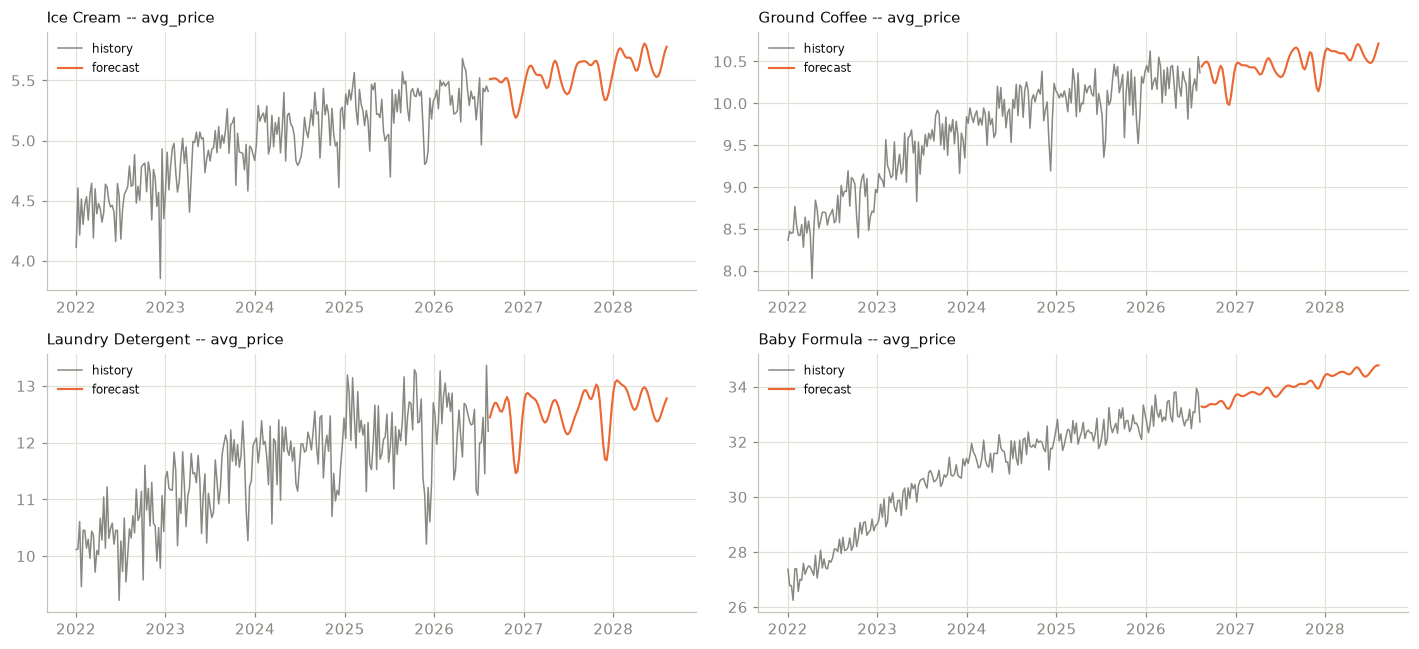

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for ax, c in zip(axes.ravel(), CATEGORIES):
    h, f = panel[panel.category == c], driver_fc[driver_fc.category == c]
    ax.plot(h["date"], h["avg_price"], color=INK_MUTED, lw=1, label="history")
    ax.plot(f["date"], f["avg_price"], color=SERIES[1], lw=1.4, label="forecast")
    ax.set_title(f"{c} -- avg_price", loc="left", fontsize=10)
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

### The baseline

Volume on those driver paths. History is always prepended before predicting so
media carryover crosses the forecast seam correctly — predicting the future rows
on their own would restart adstock at zero and understate the first weeks of every
media plan.

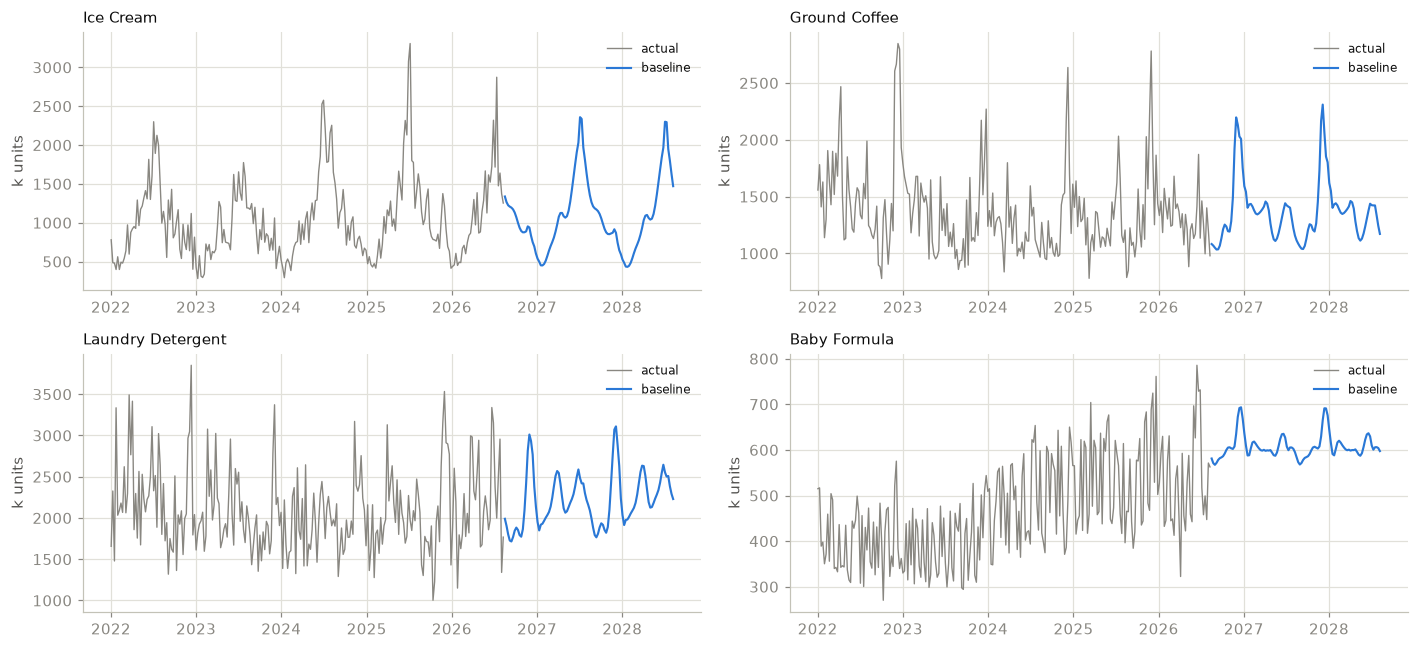

Two-year baseline volume:
category
Baby Formula          63211280.0
Ground Coffee        142811449.0
Ice Cream            113298230.0
Laundry Detergent    230995931.0


In [24]:
def predict_future(model, history, future):
    """Predict the future weeks with history prepended, then return only the future.

    Also returns each driver's log level, which the scenario waterfall needs and
    which must come from the same adstocked frame the prediction used.
    """
    cols = ["date"] + model.drivers
    combined = pd.concat([history[cols], future[cols]], ignore_index=True)
    combined = combined.sort_values("date").reset_index(drop=True)

    combined["volume_pred"] = model.predict(combined)
    adstocked = apply_adstock(combined, model.adstock_decay).reset_index(drop=True)
    for d in model.drivers:
        combined[f"l_{d}"] = log_driver(adstocked[d].to_numpy(), d)

    return combined[combined["date"] > pd.Timestamp(HISTORY_END)].reset_index(drop=True)


def baseline_table(model, panel, driver_fc):
    """The downloadable file: history and forecast, one row per week.

    Only this category's SELECTED drivers appear. A planner cannot edit a driver
    the model does not use, because the tool would silently ignore it.
    """
    c = model.category
    hist = panel[panel.category == c].sort_values("date").reset_index(drop=True)
    fut = predict_future(model, hist, driver_fc[driver_fc.category == c].sort_values("date"))

    h = pd.DataFrame({"date": hist["date"], "category": c, "period": "history",
                      "volume_actual": hist["volume"].to_numpy(),
                      "volume_baseline": model.predict(hist)})
    f = pd.DataFrame({"date": fut["date"], "category": c, "period": "forecast",
                      "volume_actual": np.nan,
                      "volume_baseline": fut["volume_pred"].to_numpy()})
    for d in model.drivers:
        h[d] = hist[d].to_numpy()
        f[d] = fut[d].to_numpy()
    return pd.concat([h, f], ignore_index=True)


baseline = pd.concat([baseline_table(models[c], panel, driver_fc) for c in CATEGORIES],
                     ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for ax, c in zip(axes.ravel(), CATEGORIES):
    b = baseline[baseline.category == c]
    h, f = b[b.period == "history"], b[b.period == "forecast"]
    ax.plot(h["date"], h["volume_actual"] / 1e3, color=INK_MUTED, lw=0.9, label="actual")
    ax.plot(f["date"], f["volume_baseline"] / 1e3, color=SERIES[0], lw=1.4, label="baseline")
    ax.set_title(c, loc="left", fontsize=10); ax.set_ylabel("k units")
    ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

print("Two-year baseline volume:")
print(baseline[baseline.period == "forecast"].groupby("category")["volume_baseline"]
      .sum().round(0).to_string())

## 10. A scenario

The loop the Streamlit app implements:

```
download  ->  a CSV of this category's drivers, history and forecast together
edit      ->  in Excel, by whoever knows the plan
upload    ->  the edited forecast rows become the scenario
```

A file rather than sliders, because a slider can only say "everything moves by
X%". A real plan is "price holds until March then rises 4%, and we pull the May
display event forward two weeks" — a column of numbers.

Only `period == 'forecast'` rows are read back. History is context for media
carryover; editing it would move the actuals line, which is not a scenario.

Below, the edit is done in pandas instead of Excel, but it is the identical code
path an upload takes.

In [25]:
def validate_upload(edited, model, driver_fc):
    """Return a list of problems with an uploaded file. Empty list means usable."""
    problems = []
    for col in ["date", "period"]:
        if col not in edited.columns:
            problems.append(f"missing required column `{col}`")
    if problems:
        return problems

    missing = [d for d in model.drivers if d not in edited.columns]
    if missing:
        problems.append(f"missing driver columns: {', '.join(missing)}")

    fut = edited[edited["period"] == "forecast"]
    if fut.empty:
        problems.append("no rows with period='forecast' -- nothing to plan")
        return problems

    expected = set(pd.DatetimeIndex(
        driver_fc[driver_fc.category == model.category]["date"]))
    got = set(pd.DatetimeIndex(fut["date"]))
    if got - expected:
        problems.append(f"{len(got - expected)} forecast dates are not in the horizon")
    if expected - got:
        problems.append(f"{len(expected - got)} forecast weeks are missing")

    for d in model.drivers:
        if d in fut.columns:
            vals = pd.to_numeric(fut[d], errors="coerce")
            if vals.isna().any():
                problems.append(f"`{d}` has {int(vals.isna().sum())} blank/non-numeric values")
            elif (vals < 0).any():
                problems.append(f"`{d}` has negative values")
    return problems


def run_scenario(model, panel, driver_fc, edited):
    """Baseline vs an edited driver plan, with a per-driver waterfall."""
    c = model.category
    hist = panel[panel.category == c].sort_values("date")
    base_fut = driver_fc[driver_fc.category == c].sort_values("date")

    scen_fut = edited[edited["period"] == "forecast"].copy()
    scen_fut["date"] = pd.to_datetime(scen_fut["date"])
    scen_fut = scen_fut.sort_values("date").reset_index(drop=True)
    for d in model.drivers:
        scen_fut[d] = pd.to_numeric(scen_fut[d], errors="coerce")

    base = predict_future(model, hist, base_fut)
    scen = predict_future(model, hist, scen_fut)

    paths = pd.DataFrame({"date": base["date"],
                          "baseline": base["volume_pred"].to_numpy(),
                          "scenario": scen["volume_pred"].to_numpy()})
    paths["delta"] = paths["scenario"] - paths["baseline"]

    # Allocate the total delta across drivers in proportion to their log
    # contributions, so the parts sum exactly to the whole.
    dlog = pd.DataFrame(index=base.index)
    for d in model.drivers:
        dlog[d] = float(model.elasticities[d]) * (
            scen[f"l_{d}"].to_numpy() - base[f"l_{d}"].to_numpy())
    total_dlog = dlog.sum(axis=1).to_numpy()
    denom = np.where(np.abs(total_dlog) < 1e-12, np.nan, total_dlog)
    delta = paths["delta"].to_numpy()

    rows = []
    for d in model.drivers:
        share = np.where(np.isnan(denom), 0.0, dlog[d].to_numpy() / denom)
        v = float(np.nansum(delta * share))
        if abs(v) > 1e-6:
            rows.append({"driver": d, "label": DRIVERS[d]["label"], "delta_volume": v})

    total_base = float(paths["baseline"].sum())
    total_scen = float(paths["scenario"].sum())
    wf = pd.DataFrame(rows, columns=["driver", "label", "delta_volume"])
    if len(wf):
        wf["delta_pct"] = 100.0 * wf["delta_volume"] / total_base
        wf = wf.sort_values("delta_volume", key=abs, ascending=False).reset_index(drop=True)

    # What actually changed in the plan, for a human-readable diff.
    changes = []
    for d in model.drivers:
        b, s = base_fut[d].to_numpy(dtype=float), scen_fut[d].to_numpy(dtype=float)
        if len(b) == len(s) and not np.allclose(b, s, rtol=1e-9, atol=1e-12):
            changes.append({"driver": d, "label": DRIVERS[d]["label"],
                            "baseline_avg": float(np.mean(b)),
                            "scenario_avg": float(np.mean(s)),
                            "pct_change": float((np.mean(s) / np.mean(b) - 1) * 100),
                            "weeks_changed": int(np.sum(~np.isclose(b, s, rtol=1e-9)))})

    return {"paths": paths, "waterfall": wf, "changes": pd.DataFrame(changes),
            "summary": {"baseline_volume": total_base, "scenario_volume": total_scen,
                        "delta_volume": total_scen - total_base,
                        "delta_pct": 100.0 * (total_scen / total_base - 1)}}


print("scenario functions defined")

scenario functions defined


In [26]:
cat2 = "Ice Cream"
m2 = models[cat2]
edited = baseline[baseline.category == cat2].copy()
fut = edited["period"] == "forecast"

# The plan: +4% price from 2027, and a heavier summer media push.
edited.loc[fut & (edited.date.dt.year >= 2027), "avg_price"] *= 1.04
edited.loc[fut & edited.date.dt.month.isin([5, 6, 7]), "tv_grps"] *= 1.5

print("Validation:", validate_upload(edited, m2, driver_fc) or "file is usable")

r = run_scenario(m2, panel, driver_fc, edited)
s = r["summary"]
print(f"\nBaseline  {s['baseline_volume']:>14,.0f}")
print(f"Scenario  {s['scenario_volume']:>14,.0f}")
print(f"Change    {s['delta_volume']:>+14,.0f}   ({s['delta_pct']:+.2f}%)")

Validation: file is usable

Baseline     113,298,230
Scenario     107,312,185
Change        -5,986,045   (-5.28%)


What changed in the plan:


,driver,label,baseline_avg,scenario_avg,pct_change,weeks_changed
0,avg_price,Average price ($/unit),5.56,5.74,3.25,84
1,tv_grps,TV GRPs,52.97,60.51,14.24,26



Where the volume difference comes from:


,driver,label,delta_volume,delta_pct
0,avg_price,Average price ($/unit),-7426028.4,-6.6
1,tv_grps,TV GRPs,1439983.8,1.3


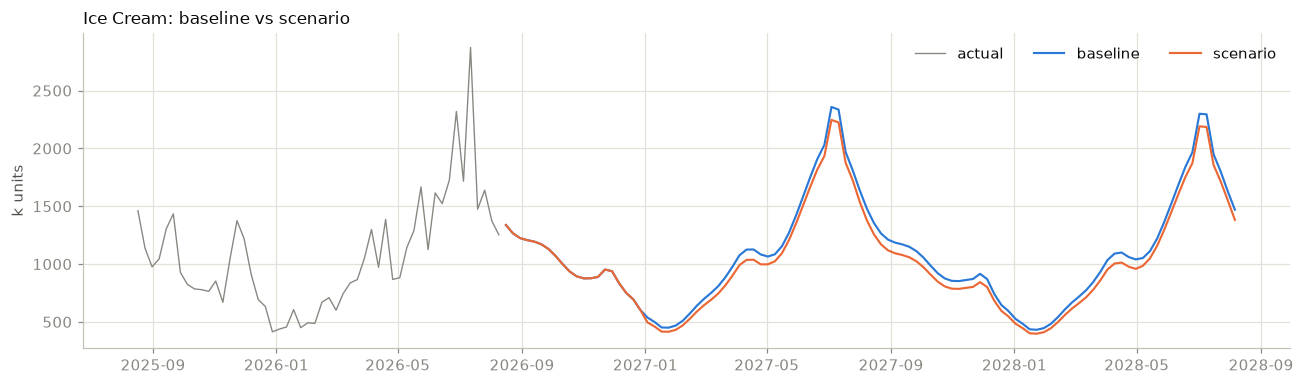

In [27]:
print("What changed in the plan:")
display(r["changes"].round(2))
print("\nWhere the volume difference comes from:")
display(r["waterfall"].round(1))

fig, ax = plt.subplots()
p = r["paths"]
h = panel[panel.category == cat2].tail(52)
ax.plot(h["date"], h["volume"] / 1e3, color=INK_MUTED, lw=0.9, label="actual")
ax.plot(p["date"], p["baseline"] / 1e3, color=SERIES[0], lw=1.4, label="baseline")
ax.plot(p["date"], p["scenario"] / 1e3, color=SERIES[1], lw=1.4, label="scenario")
ax.set_ylabel("k units"); ax.legend(frameon=False, ncol=3)
ax.set_title(f"{cat2}: baseline vs scenario", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

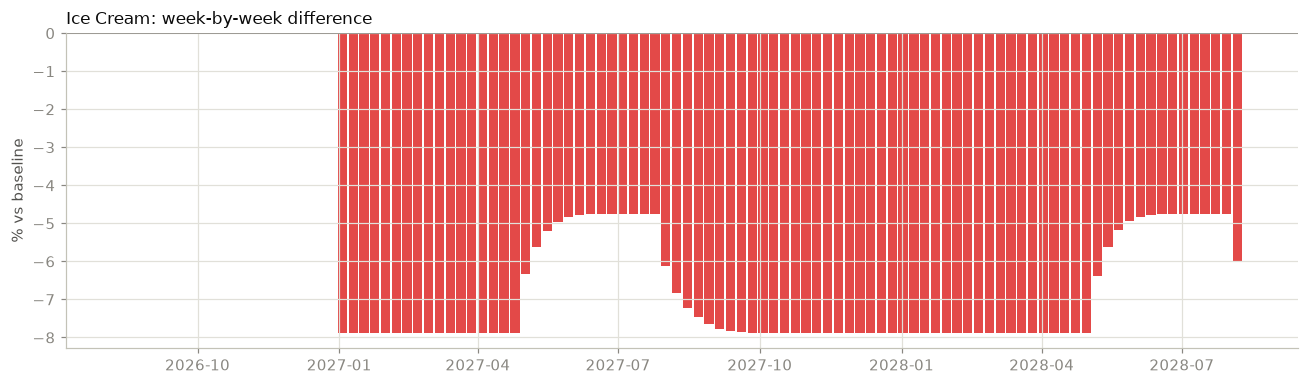

In [28]:
# The shape of the difference is the interesting part.
p = r["paths"].copy()
p["pct"] = 100 * p["delta"] / p["baseline"]
fig, ax = plt.subplots()
ax.bar(p["date"], p["pct"], width=6,
       color=[POS if v > 0 else NEG for v in p["pct"]])
ax.axhline(0, color=INK_MUTED, lw=1)
ax.set_ylabel("% vs baseline")
ax.set_title(f"{cat2}: week-by-week difference", loc="left", fontsize=11)
plt.tight_layout(); plt.show()

Note the shape: the media uplift only appears in summer weeks, and it decays for a
few weeks after each burst rather than stopping dead — that is the validated
adstock carrying over. The price effect only starts in 2027. The model responds to
*when* the plan changes, not just to how much.

## What to take away

- **Per-category selection changed the answer, not just the presentation.** The
  four categories kept different drivers and validated to different seasonal and
  carryover settings. A single shared model would have imposed one of those on all
  four.
- **Cross-validated error is not the same objective as decision support.** Left to
  itself it dropped the price lever from a category because a correlated non-lever
  forecast just as well. Forecast quality was indifferent; the tool was not.
- **The known limits of this run.** Baby formula keeps `avg_temp_c`, whose true
  elasticity is zero — a false positive that survived because it is harmless to
  forecast error and temperature carries no sign prior to test it against. Ice
  cream's test year is biased around −8%, which is the unobserved AR(1) factor
  sitting high across that particular 52 weeks rather than a fixable modelling
  error — the same model has ~3% train MAPE. One synthetic panel, one seed: the
  ordering of results is stable, individual driver decisions less so.